In [1]:
import pandas as pd
import numpy as np
from faker import Faker
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pickle
import random
from datetime import datetime
from sqlalchemy import create_engine, text
import os
import pathlib

fake = Faker('pt_BR')
np.random.seed(99)
random.seed(99)

BASE_DIR = pathlib.Path(os.getcwd())
if BASE_DIR.name == 'notebooks':
    BASE_DIR = BASE_DIR.parent

DB_PATH = BASE_DIR / 'data' / 'banco.db'
engine  = create_engine(f'sqlite:///{DB_PATH}', echo=False)

df_base  = pd.read_sql('SELECT * FROM tb_clientes', engine)
df_cl    = pd.read_sql('SELECT id_cliente, cluster_id, cluster_nome FROM tb_clusters', engine)
df_base  = df_base.drop(columns=['cluster_id','cluster_nome'], errors='ignore')
df_base  = df_base.merge(df_cl, on='id_cliente', how='left')

df_geo   = pd.read_sql('SELECT * FROM tb_estados_cidades', engine)
df_prof  = pd.read_sql('SELECT * FROM tb_ibge_salarios', engine)

with open(BASE_DIR / 'models' / 'scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open(BASE_DIR / 'models' / 'kmeans.pkl', 'rb') as f:
    km = pickle.load(f)
with open(BASE_DIR / 'models' / 'mapa_clusters.pkl', 'rb') as f:
    mapa_clusters = pickle.load(f)

NOMES_CLUSTERS = {
    0: 'Primeiros Passos',
    1: 'Trajetória Crescente',
    2: 'Potencial Oculto',
    3: 'Self Made',
    4: 'Old Money',
}

# Ordem exata do scaler treinado no notebook 02
FEATURES_MODELO = [
    'renda_mensal', 'salario_referencia', 'score_credito', 'saldo_medio',
    'media_transacoes_mes', 'meses_relacionamento', 'uso_app_dias_mes',
    'volume_cambio_usd', 'qtd_produtos', 'qtd_upgrades', 'idade',
]

print(f"Base carregada: {len(df_base):,} clientes")
print(f"Modelos carregados: scaler, kmeans, mapa_clusters")
print(f"Geo: {len(df_geo)} localidades | Prof: {len(df_prof)} profissões")
print(f"\nFeatures do scaler: {scaler.feature_names_in_.tolist()}")
print(f"Features do modelo: {FEATURES_MODELO}")
print(f"Compatível: {scaler.feature_names_in_.tolist() == FEATURES_MODELO}")

Base carregada: 300,000 clientes
Modelos carregados: scaler, kmeans, mapa_clusters
Geo: 64 localidades | Prof: 69 profissões

Features do scaler: ['renda_mensal', 'salario_referencia', 'score_credito', 'saldo_medio', 'media_transacoes_mes', 'meses_relacionamento', 'uso_app_dias_mes', 'volume_cambio_usd', 'qtd_produtos', 'qtd_upgrades', 'idade']
Features do modelo: ['renda_mensal', 'salario_referencia', 'score_credito', 'saldo_medio', 'media_transacoes_mes', 'meses_relacionamento', 'uso_app_dias_mes', 'volume_cambio_usd', 'qtd_produtos', 'qtd_upgrades', 'idade']
Compatível: True


In [2]:
PERFIS = {
    'primeiros_passos': {
        'peso': 0.05, 'renda_min': 800,   'renda_max': 2500,
        'idade_min': 18, 'idade_max': 26,
        'setores': ['Serviços','Logística','Indústria'],
    },
    'trajetoria_crescente': {
        'peso': 0.35, 'renda_min': 2500,  'renda_max': 8000,
        'idade_min': 25, 'idade_max': 45,
        'setores': ['Financeiro','Educação','Comercial','Engenharia'],
    },
    'potencial_oculto': {
        'peso': 0.30, 'renda_min': 6000,  'renda_max': 20000,
        'idade_min': 28, 'idade_max': 50,
        'setores': ['Tecnologia','Saúde','Comunicação'],
    },
    'self_made': {
        'peso': 0.25, 'renda_min': 15000, 'renda_max': 60000,
        'idade_min': 30, 'idade_max': 55,
        'setores': ['Gestão','Jurídico','Tecnologia'],
    },
    'old_money': {
        'peso': 0.05, 'renda_min': 50000, 'renda_max': 120000,
        'idade_min': 40, 'idade_max': 70,
        'setores': ['Alta Renda'],
    },
}

def sortear_profissao(perfil_cfg, df_prof):
    df_f = df_prof[df_prof['setor'].isin(perfil_cfg['setores'])]
    if len(df_f) == 0:
        df_f = df_prof
    return df_f.sample(1).iloc[0]

def sortear_localidade(df_geo):
    row = df_geo.sample(1, weights='peso').iloc[0]
    return row['uf'], row['estado'], row['regiao'], row['cidade']

def gerar_score(renda, inadimplente, idade):
    base = 400 + (renda/120000)*450 + (idade/70)*100
    if inadimplente:
        base -= np.random.uniform(100, 250)
    return int(np.clip(base + np.random.normal(0, 30), 0, 1000))

def gerar_produtos(perfil_nome, renda, score):
    probs = {
        'primeiros_passos':    {'tem_cartao_credito':0.35,'tem_credito_pessoal':0.15,'tem_financiamento':0.05,'tem_investimento':0.08,'tem_seguro':0.05,'tem_consorcio':0.03,'tem_previdencia':0.03,'tem_credito_imobiliario':0.00,'tem_cambio':0.00,'tem_cheque_especial':0.20},
        'trajetoria_crescente':{'tem_cartao_credito':0.75,'tem_credito_pessoal':0.40,'tem_financiamento':0.35,'tem_investimento':0.30,'tem_seguro':0.45,'tem_consorcio':0.20,'tem_previdencia':0.25,'tem_credito_imobiliario':0.10,'tem_cambio':0.05,'tem_cheque_especial':0.35},
        'potencial_oculto':    {'tem_cartao_credito':0.85,'tem_credito_pessoal':0.30,'tem_financiamento':0.30,'tem_investimento':0.40,'tem_seguro':0.30,'tem_consorcio':0.15,'tem_previdencia':0.25,'tem_credito_imobiliario':0.20,'tem_cambio':0.15,'tem_cheque_especial':0.20},
        'self_made':           {'tem_cartao_credito':0.95,'tem_credito_pessoal':0.25,'tem_financiamento':0.45,'tem_investimento':0.75,'tem_seguro':0.55,'tem_consorcio':0.25,'tem_previdencia':0.60,'tem_credito_imobiliario':0.45,'tem_cambio':0.40,'tem_cheque_especial':0.10},
        'old_money':           {'tem_cartao_credito':0.99,'tem_credito_pessoal':0.10,'tem_financiamento':0.20,'tem_investimento':0.95,'tem_seguro':0.80,'tem_consorcio':0.30,'tem_previdencia':0.90,'tem_credito_imobiliario':0.70,'tem_cambio':0.80,'tem_cheque_especial':0.00},
    }
    p = {'tem_conta_corrente': 1}
    for col, prob in probs[perfil_nome].items():
        p[col] = int(random.random() < prob)
    p['qtd_produtos'] = sum(v for k,v in p.items() if k.startswith('tem_'))
    p['upgrade_cartao_black']        = int(random.random() < (0.80 if p['tem_cartao_credito'] and renda>15000 else 0.0))
    p['upgrade_investimento_plus']   = int(random.random() < (0.70 if p['tem_investimento'] and perfil_nome in ['self_made','old_money'] else 0.0))
    p['upgrade_limite_credito']      = int(random.random() < (0.50 if p['tem_credito_pessoal'] and score>600 else 0.0))
    p['upgrade_credito_imobiliario'] = int(random.random() < (0.40 if p['tem_financiamento'] and renda>6000 else 0.0))
    p['upgrade_limite_cheque']       = int(random.random() < (0.45 if p['tem_cheque_especial'] and score>500 else 0.0))
    p['upgrade_conta_global']        = int(random.random() < (0.60 if p['tem_cambio'] and perfil_nome in ['self_made','old_money'] else 0.0))
    p['qtd_upgrades']                = sum(v for k,v in p.items() if k.startswith('upgrade_'))
    return p

def gerar_comportamento(renda, perfil_nome):
    txn = int(renda/300)
    inadim_prob = {'primeiros_passos':0.15,'trajetoria_crescente':0.08,'potencial_oculto':0.05,'self_made':0.03,'old_money':0.01}
    meses_rel   = {'primeiros_passos':(1,12),'trajetoria_crescente':(24,180),'potencial_oculto':(12,120),'self_made':(36,240),'old_money':(60,240)}
    mn, mx = meses_rel[perfil_nome]
    return {
        'media_transacoes_mes':   max(1, int(np.random.normal(txn, txn*0.3))),
        'saldo_medio':            round(np.random.lognormal(np.log(max(100, renda*0.4)), 0.5), 2),
        'uso_app_dias_mes':       min(30, max(0, int(np.random.normal(22 if perfil_nome=='primeiros_passos' else 14, 5)))),
        'meses_relacionamento':   1,
        'teve_inadimplencia_12m': int(random.random() < inadim_prob[perfil_nome]),
        'volume_cambio_usd':      round(np.random.lognormal(6, 0.8), 2) if perfil_nome in ['self_made','old_money'] else 0.0,
    }

print("Funções definidas!")

Funções definidas!


In [3]:
def classificar_novos(df_novos):
    X = df_novos[FEATURES_MODELO]
    X_scaled = scaler.transform(X)
    clusters_raw = km.predict(X_scaled)
    df_novos = df_novos.copy()
    df_novos['cluster_id']   = [mapa_clusters.get(c, c) for c in clusters_raw]
    df_novos['cluster_nome'] = df_novos['cluster_id'].map(NOMES_CLUSTERS)
    return df_novos

ultimo_id = len(df_base)
meses     = ['2025-02','2025-03','2025-04']
dfs_novos = []

perfil_nomes = list(PERFIS.keys())
pesos        = [PERFIS[p]['peso'] for p in perfil_nomes]

print("Simulando entrada de novos clientes...\n")
for mes in meses:
    n_novos  = random.randint(800, 1200)
    registros = []

    for i in range(n_novos):
        perfil_nome = random.choices(perfil_nomes, weights=pesos, k=1)[0]
        cfg         = PERFIS[perfil_nome]
        prof        = sortear_profissao(cfg, df_prof)
        uf, estado, regiao, cidade = sortear_localidade(df_geo)

        renda_base = float(prof['salario_medio'])
        renda      = round(float(np.clip(
            np.random.lognormal(np.log(max(800, renda_base)), 0.25),
            cfg['renda_min'], cfg['renda_max']
        )), 2)

        idade  = random.randint(cfg['idade_min'], cfg['idade_max'])
        inadim = random.random() < 0.08
        score  = gerar_score(renda, inadim, idade)
        prods  = gerar_produtos(perfil_nome, renda, score)
        comp   = gerar_comportamento(renda, perfil_nome)

        registros.append({
            'id_cliente':         f'CLI{str(ultimo_id + i + 1).zfill(6)}',
            'mes_entrada':        mes,
            'nome':               fake.name(),
            'email':              fake.email(),
            'cpf':                fake.cpf(),
            'data_nascimento':    fake.date_of_birth(minimum_age=idade, maximum_age=idade).strftime('%Y-%m-%d'),
            'idade':              idade,
            'telefone':           fake.phone_number(),
            'uf':                 uf,
            'estado':             estado,
            'regiao':             regiao,
            'cidade':             cidade,
            'profissao':          prof['profissao'],
            'setor':              prof['setor'],
            'salario_referencia': float(prof['salario_medio']),
            'renda_mensal':       renda,
            'score_credito':      score,
            'perfil_real':        perfil_nome,
            **prods,
            **comp,
        })

    df_novos = pd.DataFrame(registros)
    df_novos = classificar_novos(df_novos)
    dfs_novos.append(df_novos)
    ultimo_id += n_novos

    print(f"Mês {mes}: {n_novos:,} novos clientes")
    print(f"  {df_novos['cluster_nome'].value_counts().to_dict()}\n")

df_incremento = pd.concat(dfs_novos, ignore_index=True)
print(f"Total novos: {len(df_incremento):,}")

Simulando entrada de novos clientes...



c:\Users\caleb\Documents\SANTANDER-MOTOR-RECOMENDACAO\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


Mês 2025-02: 1,006 novos clientes
  {'Trajetória Crescente': 352, 'Potencial Oculto': 243, 'Primeiros Passos': 203, 'Self Made': 168, 'Old Money': 40}



c:\Users\caleb\Documents\SANTANDER-MOTOR-RECOMENDACAO\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


Mês 2025-03: 808 novos clientes
  {'Trajetória Crescente': 298, 'Potencial Oculto': 219, 'Primeiros Passos': 147, 'Self Made': 114, 'Old Money': 30}



Mês 2025-04: 971 novos clientes
  {'Trajetória Crescente': 351, 'Potencial Oculto': 245, 'Primeiros Passos': 202, 'Self Made': 141, 'Old Money': 32}

Total novos: 2,785


c:\Users\caleb\Documents\SANTANDER-MOTOR-RECOMENDACAO\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [4]:
print("Features do scaler:")
print(scaler.feature_names_in_.tolist())

Features do scaler:
['renda_mensal', 'salario_referencia', 'score_credito', 'saldo_medio', 'media_transacoes_mes', 'meses_relacionamento', 'uso_app_dias_mes', 'volume_cambio_usd', 'qtd_produtos', 'qtd_upgrades', 'idade']


Base original:    300,000
Novos clientes:   2,785
Base consolidada: 302,785

Distribuição % por mês:
cluster_nome  Old Money  Potencial Oculto  Primeiros Passos  Self Made  \
mes_entrada                                                              
2025-01             5.1              31.4               9.3       21.4   
2025-02             4.0              24.2              20.2       16.7   
2025-03             3.7              27.1              18.2       14.1   
2025-04             3.3              25.2              20.8       14.5   

cluster_nome  Trajetória Crescente  
mes_entrada                         
2025-01                       32.9  
2025-02                       35.0  
2025-03                       36.9  
2025-04                       36.1  

Drift detectado (Jan vs Abr):
  ↓ Old Money: -1.8pp
  ↓ Potencial Oculto: -6.2pp
  ↑ Primeiros Passos: +11.5pp
  ↓ Self Made: -6.8pp
  ↑ Trajetória Crescente: +3.2pp


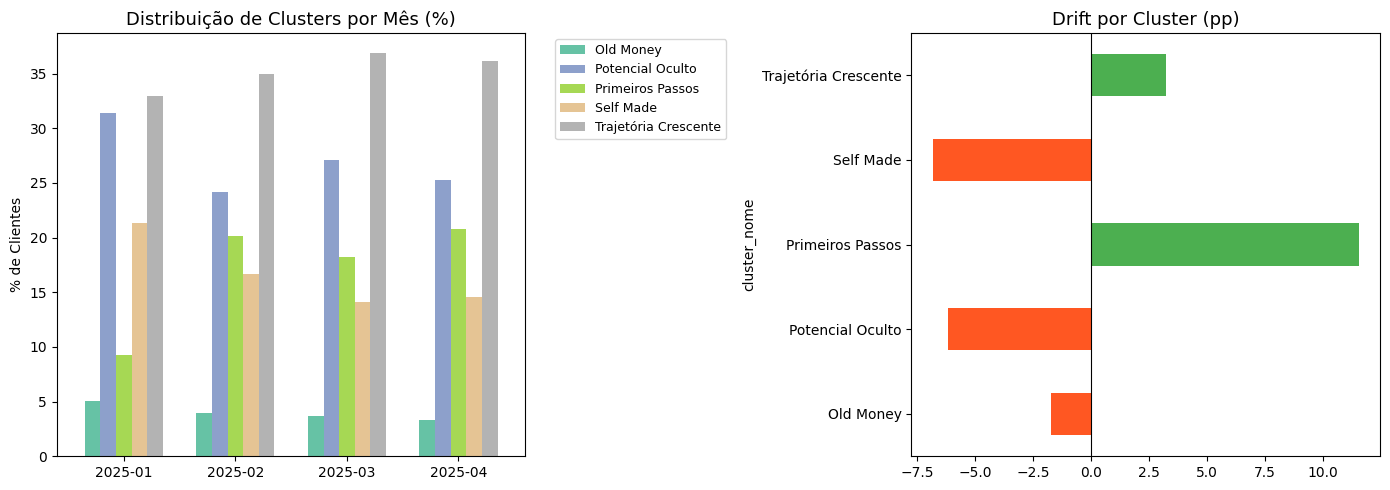

In [5]:
import matplotlib.pyplot as plt

df_base['mes_entrada'] = '2025-01'

cols_comuns = [c for c in df_base.columns if c in df_incremento.columns]
df_completo = pd.concat([
    df_base[cols_comuns],
    df_incremento[cols_comuns]
], ignore_index=True)

print(f"Base original:    {len(df_base):,}")
print(f"Novos clientes:   {len(df_incremento):,}")
print(f"Base consolidada: {len(df_completo):,}")

evolucao = df_completo.groupby(['mes_entrada','cluster_nome']).size().unstack(fill_value=0)
evolucao_pct = evolucao.div(evolucao.sum(axis=1), axis=0) * 100

print(f"\nDistribuição % por mês:")
print(evolucao_pct.round(1))

drift = evolucao_pct.iloc[-1] - evolucao_pct.iloc[0]
print(f"\nDrift detectado (Jan vs Abr):")
for cluster, variacao in drift.items():
    sinal = '↑' if variacao > 0 else '↓'
    print(f"  {sinal} {cluster}: {variacao:+.1f}pp")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
evolucao_pct.plot(kind='bar', ax=axes[0], colormap='Set2', width=0.7)
axes[0].set_title('Distribuição de Clusters por Mês (%)', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('% de Clientes')
axes[0].legend(bbox_to_anchor=(1.05,1), loc='upper left', fontsize=9)
axes[0].tick_params(axis='x', rotation=0)

drift.plot(kind='barh', ax=axes[1],
           color=['#4CAF50' if v>0 else '#FF5722' for v in drift])
axes[1].set_title('Drift por Cluster (pp)', fontsize=13)
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig(str(BASE_DIR / 'docs' / 'pipeline_drift.png'), dpi=150, bbox_inches='tight')
plt.show()